In [2]:
# Cell 1 — Setup + Diagnostic
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "fyxical-poc"
DATASET = "fyxical_poc"

client = bigquery.Client(project=PROJECT_ID)

# Diagnostic
print("1. Testing connection...")
test = client.query("SELECT 1 as test").to_dataframe()
print(f"✅ Connection OK: {test}")

print("\n2. Listing datasets...")
for ds in client.list_datasets():
    print(f"   📁 {ds.dataset_id}")

print("\n3. Listing tables in fyxical_poc...")
for table in client.list_tables(DATASET):
    print(f"   📋 {table.table_id}")

1. Testing connection...
✅ Connection OK:    test
0     1

2. Listing datasets...
   📁 fyxical_poc

3. Listing tables in fyxical_poc...
   📋 patient_intake


In [3]:
# 03 - Rule-Based Decision Tree MVP
# Fyxical POC | Lower Back Pain Clinical Decision Support

from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "fyxical-poc"
DATASET = "fyxical_poc"
client = bigquery.Client(project=PROJECT_ID)

patients = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.patient_intake`
""").to_dataframe()

print(f"✅ {len(patients)} patients loaded")

✅ 500 patients loaded


In [4]:
def assign_pathway(row):
    # Priority 1: Red flags → immediate referral (use osw score as proxy)
    if row['osw_baseline_percent_disability'] >= 80:
        return 'Urgent Referral'
    
    # Priority 2: Chronic + high disability
    elif row['pain_duration_category'] == 'Chronic' and \
         row['osw_baseline_percent_disability'] >= 40:
        return 'Long-term Management + Referral'
    
    # Priority 3: Acute + mild/moderate
    elif row['pain_duration_category'] == 'Acute' and \
         row['pain_severity_score_0_10'] <= 5:
        return 'Home Exercise Program'
    
    # Priority 4: Subacute
    elif row['pain_duration_category'] == 'Subacute':
        return 'Standard Progression'
    
    # Priority 5: Acute + severe
    elif row['pain_duration_category'] == 'Acute' and \
         row['pain_severity_score_0_10'] > 5:
        return 'In-Clinic Progression'
    
    # Default
    else:
        return 'Standard Progression'

patients['recommended_pathway'] = patients.apply(assign_pathway, axis=1)
print("✅ Pathways assigned!")
print(patients['recommended_pathway'].value_counts())

✅ Pathways assigned!
recommended_pathway
Standard Progression               233
Long-term Management + Referral    126
In-Clinic Progression               71
Home Exercise Program               70
Name: count, dtype: int64


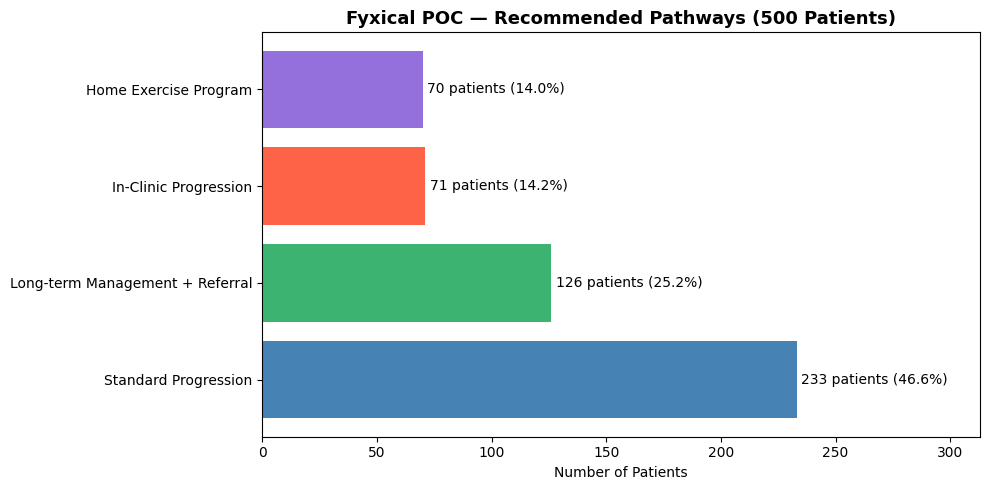

✅ Chart saved!


In [5]:
import matplotlib.pyplot as plt

pathway_counts = patients['recommended_pathway'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pathway_counts.index, pathway_counts.values, 
               color=['steelblue','mediumseagreen','tomato','mediumpurple','darkorange'])

for bar, val in zip(bars, pathway_counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val} patients ({val/len(patients)*100:.1f}%)',
            va='center', fontsize=10)

ax.set_title('Fyxical POC — Recommended Pathways (500 Patients)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Patients')
ax.set_xlim(0, pathway_counts.max() + 80)
plt.tight_layout()
plt.savefig('pathway_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [6]:
print("=== PATHWAY BREAKDOWN ===")

print("\nAvg Pain Severity by Pathway:")
print(patients.groupby('recommended_pathway')['pain_severity_score_0_10'].mean().round(2))

print("\nAvg OSW Disability % by Pathway:")
print(patients.groupby('recommended_pathway')['osw_baseline_percent_disability'].mean().round(2))

print("\nAvg Age by Pathway:")
print(patients.groupby('recommended_pathway')['age'].mean().round(1))

print("\nWork-Related Injury by Pathway:")
print(pd.crosstab(patients['recommended_pathway'], patients['work_related_injury']))

=== PATHWAY BREAKDOWN ===

Avg Pain Severity by Pathway:
recommended_pathway
Home Exercise Program              3.57
In-Clinic Progression              7.69
Long-term Management + Referral    7.29
Standard Progression               5.05
Name: pain_severity_score_0_10, dtype: Float64

Avg OSW Disability % by Pathway:
recommended_pathway
Home Exercise Program              34.77
In-Clinic Progression              51.89
Long-term Management + Referral    54.37
Standard Progression                39.8
Name: osw_baseline_percent_disability, dtype: Float64

Avg Age by Pathway:
recommended_pathway
Home Exercise Program              49.0
In-Clinic Progression              47.8
Long-term Management + Referral    50.4
Standard Progression               47.3
Name: age, dtype: Float64

Work-Related Injury by Pathway:
work_related_injury               No  Unsure  Yes
recommended_pathway                              
Home Exercise Program             46       9   15
In-Clinic Progression             

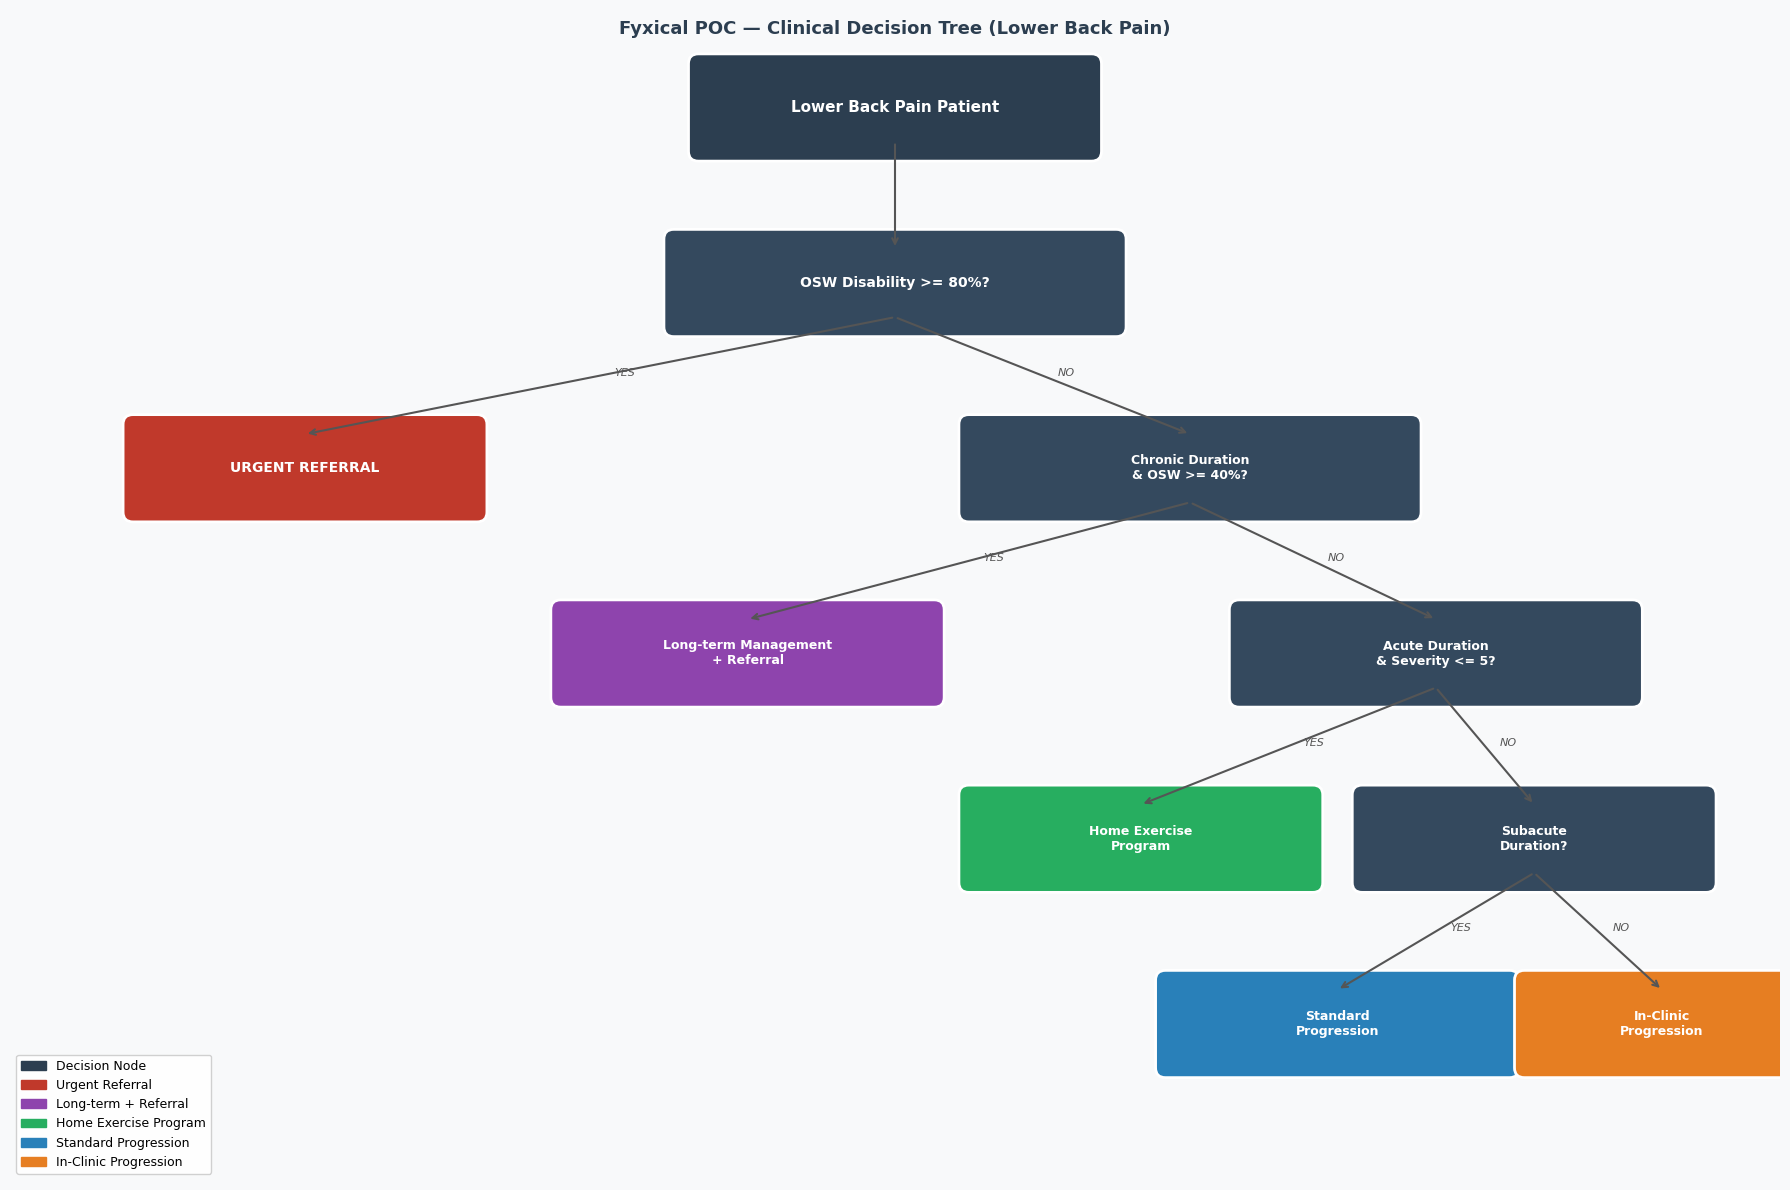

✅ Decision tree saved as decision_tree_visualization.png


In [10]:
# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 12)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

def draw_box(ax, x, y, width, height, text, color, fontsize=9, text_color='white'):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color=text_color, fontweight='bold', multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2+0.35), xytext=(x1, y1-0.35),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=8, color=color, fontstyle='italic')

# Root node
draw_box(ax, 9, 11, 4, 0.9, 'Lower Back Pain Patient', '#2c3e50', fontsize=11)

# Level 1
draw_box(ax, 9, 9.2, 4.5, 0.9, 'OSW Disability >= 80%?', '#34495e', fontsize=10)
draw_arrow(ax, 9, 11, 9, 9.2)

# Urgent Referral
draw_box(ax, 3, 7.3, 3.5, 0.9, 'URGENT REFERRAL', '#c0392b', fontsize=10)
draw_arrow(ax, 9, 9.2, 3, 7.3, 'YES')

# Level 2
draw_box(ax, 12, 7.3, 4.5, 0.9, 'Chronic Duration\n& OSW >= 40%?', '#34495e', fontsize=9)
draw_arrow(ax, 9, 9.2, 12, 7.3, 'NO')

# Long-term Management
draw_box(ax, 7.5, 5.4, 3.8, 0.9, 'Long-term Management\n+ Referral', '#8e44ad', fontsize=9)
draw_arrow(ax, 12, 7.3, 7.5, 5.4, 'YES')

# Level 3
draw_box(ax, 14.5, 5.4, 4, 0.9, 'Acute Duration\n& Severity <= 5?', '#34495e', fontsize=9)
draw_arrow(ax, 12, 7.3, 14.5, 5.4, 'NO')

# Home Exercise
draw_box(ax, 11.5, 3.5, 3.5, 0.9, 'Home Exercise\nProgram', '#27ae60', fontsize=9)
draw_arrow(ax, 14.5, 5.4, 11.5, 3.5, 'YES')

# Level 4
draw_box(ax, 15.5, 3.5, 3.5, 0.9, 'Subacute\nDuration?', '#34495e', fontsize=9)
draw_arrow(ax, 14.5, 5.4, 15.5, 3.5, 'NO')

# Standard Progression
draw_box(ax, 13.5, 1.6, 3.5, 0.9, 'Standard\nProgression', '#2980b9', fontsize=9)
draw_arrow(ax, 15.5, 3.5, 13.5, 1.6, 'YES')

# In-Clinic Progression
draw_box(ax, 16.8, 1.6, 2.8, 0.9, 'In-Clinic\nProgression', '#e67e22', fontsize=9)
draw_arrow(ax, 15.5, 3.5, 16.8, 1.6, 'NO')

# Title
ax.text(9, 11.8, 'Fyxical POC — Clinical Decision Tree (Lower Back Pain)',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#2c3e50')

# Legend
legend_items = [
    mpatches.Patch(color='#2c3e50', label='Decision Node'),
    mpatches.Patch(color='#c0392b', label='Urgent Referral'),
    mpatches.Patch(color='#8e44ad', label='Long-term + Referral'),
    mpatches.Patch(color='#27ae60', label='Home Exercise Program'),
    mpatches.Patch(color='#2980b9', label='Standard Progression'),
    mpatches.Patch(color='#e67e22', label='In-Clinic Progression'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Decision tree saved as decision_tree_visualization.png")

In [11]:
pathways_df = patients[['patient_id', 'recommended_pathway',
                         'pain_duration_category', 'pain_severity_score_0_10',
                         'osw_baseline_percent_disability']]

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    autodetect=True
)
job = client.load_table_from_dataframe(
    pathways_df,
    f'{PROJECT_ID}.{DATASET}.patient_pathways',
    job_config=job_config
)
job.result()
print(f"✅ {len(pathways_df)} pathway results saved to BigQuery!")
print(f"   Table: {PROJECT_ID}.{DATASET}.patient_pathways")

✅ 500 pathway results saved to BigQuery!
   Table: fyxical-poc.fyxical_poc.patient_pathways
